In [ ]:
import csv
import random

# Define the number of records you want to generate
num_records = 1000

# Define the range for generating random values
age_range = (18, 80)
treatment_duration_range = (1, 12)
dosage_range = (1, 1000)
treatment_frequency_options = ['daily', 'weekly', 'monthly']
treatment_method_options = ['Medication', 'Therapy', 'Surgery']
symptom_relief_options = ['none', 'mild', 'moderate', 'significant']
symptom_duration_range = (1, 30)
success_rate_range = (0, 100)
ethnicity_options = ['Asian', 'Black', 'Hispanic', 'White', 'Other']
disease_severity_options = ['low', 'medium', 'high']

# Generate and save the dataset as a CSV file
with open('D:/College Study Stuff/III Year/Quater-4/MED 355 HCA Y3T4/LabExpDatasets/project/patient_treatment_dataset2.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Write the header row
    writer.writerow(['Patient ID', 'Age', 'Gender', 'Medical History', 'Treatment ID', 'Treatment Type',
                     'Treatment Duration', 'Treatment Dosage', 'Treatment Frequency', 'Treatment Method',
                     'Symptom Relief', 'Symptom Duration', 'Success Rate', 'Ethnicity', 'Disease Severity',
                     'Need Dialysis'])
    
    # Generate random records
    for i in range(num_records):
        patient_id = i + 1
        age = random.randint(*age_range)
        gender = random.choice(['Male', 'Female'])
        medical_history = random.choice(['None', 'Hypertension', 'Diabetes', 'Asthma'])
        treatment_id = random.randint(1000, 9999)
        treatment_type = random.choice(treatment_method_options)
        treatment_duration = random.randint(*treatment_duration_range)
        dosage = random.randint(*dosage_range)
        treatment_frequency = random.choice(treatment_frequency_options)
        treatment_method = random.choice(treatment_method_options)
        symptom_relief = random.choice(symptom_relief_options)
        symptom_duration = random.randint(*symptom_duration_range)
        success_rate = random.randint(*success_rate_range)
        ethnicity = random.choice(ethnicity_options)
        disease_severity = random.choice(disease_severity_options)
        need_dialysis = random.choice([True, False])
        
        # Write the record to the CSV file
        writer.writerow([patient_id, age, gender, medical_history, treatment_id, treatment_type,
                         treatment_duration, dosage, treatment_frequency, treatment_method,
                         symptom_relief, symptom_duration, success_rate, ethnicity, disease_severity,
                         need_dialysis])

print("Dataset created successfully.")


In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("D:/College Study Stuff/III Year/Quater-4/MED 355 HCA Y3T4/LabExpDatasets/project/patient_treatment_dataset2.csv")
df.head(10)

,Patient ID,Age,Gender,Medical History,Treatment ID,Treatment Type,Treatment Duration,Treatment Dosage,Treatment Frequency,Treatment Method,Symptom Relief,Symptom Duration,Success Rate,Ethnicity,Disease Severity,Need Dialysis
0,1,45,Female,None,7958,Medication,10,304,weekly,Medication,moderate,17,84,White,medium,False
1,2,43,Female,Diabetes,1751,Medication,10,257,weekly,Medication,moderate,24,47,Black,high,True
2,3,56,Female,Hypertension,6227,Medication,12,616,monthly,Surgery,moderate,10,2,Hispanic,medium,False
3,4,38,Male,Asthma,5836,Medication,8,642,monthly,Medication,mild,24,12,Other,low,True
4,5,35,Male,Diabetes,2588,Medication,3,700,weekly,Therapy,significant,23,26,Hispanic,medium,True
5,6,31,Male,Diabetes,5182,Surgery,3,998,daily,Medication,mild,21,37,White,high,False
6,7,66,Male,None,6031,Surgery,1,493,daily,Therapy,none,20,92,Hispanic,high,False
7,8,40,Male,Asthma,6576,Surgery,4,497,daily,Therapy,moderate,12,52,Other,high,True
8,9,23,Female,Hypertension,8209,Therapy,1,169,daily,Therapy,significant,7,48,Hispanic,low,False
9,10,61,Female,Asthma,7797,Medication,6,323,daily,Medication,mild,1,13,Black,low,False


In [2]:
df.describe()

,Patient ID,Age,Treatment ID,Treatment Duration,Treatment Dosage,Symptom Duration,Success Rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.299000,5540.247000,6.516000,496.656000,15.779000,50.420000
std,288.819436,18.199693,2584.851413,3.505429,293.814224,8.674757,29.315269
min,1.000000,18.000000,1001.000000,1.000000,2.000000,1.000000,0.000000
25%,250.750000,34.000000,3317.250000,3.000000,226.000000,8.000000,25.000000
50%,500.500000,49.000000,5529.500000,7.000000,492.000000,16.000000,51.000000
75%,750.250000,65.000000,7740.000000,10.000000,758.000000,23.000000,75.250000
max,1000.000000,80.000000,9993.000000,12.000000,1000.000000,30.000000,100.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient ID           1000 non-null   int64 
 1   Age                  1000 non-null   int64 
 2   Gender               1000 non-null   object
 3   Medical History      1000 non-null   object
 4   Treatment ID         1000 non-null   int64 
 5   Treatment Type       1000 non-null   object
 6   Treatment Duration   1000 non-null   int64 
 7   Treatment Dosage     1000 non-null   int64 
 8   Treatment Frequency  1000 non-null   object
 9   Treatment Method     1000 non-null   object
 10  Symptom Relief       1000 non-null   object
 11  Symptom Duration     1000 non-null   int64 
 12  Success Rate         1000 non-null   int64 
 13  Ethnicity            1000 non-null   object
 14  Disease Severity     1000 non-null   object
 15  Need Dialysis        1000 non-null   bool  
dtypes: bool

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
# Separate features (X) and target variable (y)
X = df.drop('Need Dialysis', axis=1)
y = df['Need Dialysis']

# Encode categorical variables
label_encoder = LabelEncoder()
X['Gender'] = label_encoder.fit_transform(X['Gender'])
X['Medical History'] = label_encoder.fit_transform(X['Medical History'])
X['Treatment Type'] = label_encoder.fit_transform(X['Treatment Type'])
X['Treatment Frequency'] = label_encoder.fit_transform(X['Treatment Frequency'])
X['Treatment Method'] = label_encoder.fit_transform(X['Treatment Method'])
X['Ethnicity'] = label_encoder.fit_transform(X['Ethnicity'])
X['Disease Severity'] = label_encoder.fit_transform(X['Disease Severity'])


# Convert categorical variables into numerical values using one-hot encoding
X = pd.get_dummies(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [5]:
# Create a decision tree classifier
classifier = DecisionTreeClassifier()

# Train the classifier on the training set
classifier.fit(X_train, y_train)

# Make predictions on the testing set
y_pred1 = classifier.predict(X_test)

# Calculate the accuracy of the model
accuracy1 = accuracy_score(y_test, y_pred1)
print('Accuracy:', accuracy1)

Accuracy: 0.525


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create and train the logistic regression model
model1 = LogisticRegression(max_iter=10000)
model1.fit(X_train, y_train)

# Make predictions on the test set
y_pred2 = model1.predict(X_test)

# Evaluate the model's accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy2)

Accuracy: 0.485


In [7]:
from sklearn.ensemble import GradientBoostingClassifier
# Create and train the Gradient Boosting Classifier model
model2 = GradientBoostingClassifier()
model2.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred3 = model2.predict(X_test)

# Evaluate the accuracy of the model
accuracy3 = accuracy_score(y_test, y_pred3)
print(f'Accuracy: {accuracy3}')

Accuracy: 0.48


In [8]:
# Calculate the average accuracy
avg_accuracy = np.mean([accuracy1, accuracy2,accuracy3])
print("Average Accuracy:", avg_accuracy)

Average Accuracy: 0.49666666666666665


In [9]:
# Example prediction
example_data1 = X_test.iloc[0]
example_prediction1 = model1.predict([example_data1])
print(f'Example Prediction: {example_prediction1}')

Example Prediction: [ True]


In [10]:
# Example prediction
example_data2 = X_test.iloc[0]
example_prediction2 = model2.predict([example_data2])
print(f'Example Prediction: {example_prediction2}')

Example Prediction: [ True]


In [11]:
# Example prediction
example_data3 = X_test.iloc[0]
example_prediction3 = classifier.predict([example_data3])
print(f'Example Prediction: {example_prediction3}')

Example Prediction: [False]


In [12]:
# Count the predictions and find the most common one
predictions = [example_prediction1[0], example_prediction2[0], example_prediction3[0]]
most_common_prediction = max(set(predictions), key=predictions.count)

print(f"Example Predictions: {predictions}")
print(f"Most Common Prediction: {most_common_prediction}")

Example Predictions: [True, True, False]
Most Common Prediction: True


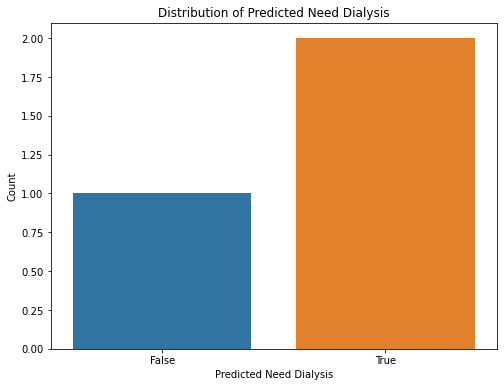

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x=predictions)
plt.xlabel('Predicted Need Dialysis')
plt.ylabel('Count')
plt.title('Distribution of Predicted Need Dialysis')
plt.show()